<a href="https://colab.research.google.com/github/MMujtabaX/RNN/blob/main/DL_S05E01_Seq_Models_IMDB_Shared.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning | Sequence Models

### Dataset: IMDB| Framework: Keras (Tensorflow)

## 🔹 1. RNN for Sentiment Classification

### ✅ Download and Explore the dataset

In [ ]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout, Bidirectional, Attention, GlobalAveragePooling1D, LayerNormalization
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

2026-03-08 07:05:11.512968: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-08 07:05:11.563334: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-08 07:05:12.648140: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [ ]:
vocab_size = 10000    # Only top 10,000 words
maxlen = 200          # each review of only 200 words

In [ ]:
# Load the dataset

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

/home/ai/miniconda3/envs/tfg/lib/python3.11/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


In [ ]:
# print shapes
print(X_train.shape)
print(y_train.shape)

(25000,)
(25000,)


In [ ]:
# Check sample review
print("Sample review:", X_train[0])
print("\nLabel:", y_train[0])

Sample review: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]

Label: 1


In [ ]:
# iterate over all the reviews and check the maximum value
print(max([max(review) for review in X_train]))

9999


In [ ]:
# Load the word index mapping (word → index)
word_index = imdb.get_word_index()

In [ ]:
word_index['amazing']

477

In [ ]:
sorted_words = sorted(word_index.items(), key=lambda x: x[1])
print(sorted_words[:10])

[('the', 1), ('and', 2), ('a', 3), ('of', 4), ('to', 5), ('is', 6), ('br', 7), ('in', 8), ('it', 9), ('i', 10)]


In [ ]:
# Create a reverse mapping (index → word)
reverse_word_index = {index + 3: word for word, index in word_index.items()}
reverse_word_index[0] = '<PAD>'
reverse_word_index[1] = '<START>'
reverse_word_index[2] = '<UNK>'
reverse_word_index[3] = '<UNUSED>'

In [ ]:
reverse_word_index[4+3]

'of'

In [ ]:
# Decode function
def decode_review(encoded_review):
    return ' '.join([reverse_word_index.get(i, '?') for i in encoded_review])

In [ ]:
# Show sample
print("Encoded Review:", X_train[0])
print("\nDecoded Review:", decode_review(X_train[0]))
print("\nLabel:", y_train[0])  # 0 = negative, 1 = positive

Encoded Review: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]

Decoded Review: <START> this film was just 

### ✅ Pad Sequences

In [ ]:
len(X_train[2])

141

In [ ]:
X_train = pad_sequences(X_train, maxlen=maxlen)
X_test = pad_sequences(X_test, maxlen=maxlen)

In [ ]:
print("Decoded Review:", decode_review(X_train[10]))

Decoded Review: feels restrained and manages to flow well throughout director eric <UNK> provides a great atmosphere for the film the fact that most of it takes place inside the central prison cell <UNK> that the film feels very claustrophobic and this immensely benefits the central idea of the prisoners wanting to use magic to break out of the cell it's very easy to get behind them it's often said that the unknown is the thing that really <UNK> people and this film proves that as the director <UNK> that we can never really be sure of exactly what is round the corner and this helps to ensure that <UNK> actually does manage to be quite frightening the film is memorable for a lot of reasons outside the central plot the characters are all very interesting in their own way and the fact that the book itself almost takes on its own character is very well done anyone worried that the film won't deliver by the end won't be disappointed either as the ending both makes sense and manages to be qu

In [ ]:
def plot_training_curves(history):
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # Accuracy plot
    axs[0].plot(history.history['accuracy'], label='Train Acc')
    axs[0].plot(history.history['val_accuracy'], label='Val Acc')
    axs[0].set_title('Accuracy')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Accuracy')
    axs[0].legend()

    # Loss plot
    axs[1].plot(history.history['loss'], label='Train Loss')
    axs[1].plot(history.history['val_loss'], label='Val Loss')
    axs[1].set_title('Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Loss')
    axs[1].legend()

    plt.tight_layout()
    plt.show()


### ✅ Build the Model

In [ ]:
model_rnn = Sequential([
    Input(shape=(maxlen,)),
    Embedding(input_dim=vocab_size, output_dim=128),
    SimpleRNN(64),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_rnn.summary()

I0000 00:00:1772935516.110401    3724 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7207 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,292,417 (4.93 MB)

 Trainable params: 1,292,417 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_rnn.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

### ✅ Train the Model

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1)

In [ ]:
# Dictionary to store model accuracies
model_accuracies = {}

In [ ]:
history_rnn = model_rnn.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=128,
    callbacks=[early_stop]
)

Epoch 1/10


2026-03-08 07:05:18.369989: I external/local_xla/xla/service/service.cc:163] XLA service 0x70601c004f20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-08 07:05:18.370028: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3080, Compute Capability 8.6
2026-03-08 07:05:18.395858: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-08 07:05:18.536163: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-03-08 07:05:18.602560: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-08 07:05:18.602621: I e

  5/157 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.5045 - loss: 0.7017

I0000 00:00:1772935521.125524    4105 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


155/157 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5697 - loss: 0.6700

2026-03-08 07:05:26.034361: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-08 07:05:26.034427: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-08 07:05:26.034444: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-08 07:05:26.958338: I external/l

157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - accuracy: 0.6367 - loss: 0.6330 - val_accuracy: 0.7848 - val_loss: 0.4786
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.8338 - loss: 0.3859 - val_accuracy: 0.7968 - val_loss: 0.4465
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.9100 - loss: 0.2351 - val_accuracy: 0.8140 - val_loss: 0.4615
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9684 - loss: 0.1005 - val_accuracy: 0.8414 - val_loss: 0.4680
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9908 - loss: 0.0373 - val_accuracy: 0.8084 - val_loss: 0.5851
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9945 - loss: 0.0229 - val_accuracy: 0.8154 - val_loss: 0.6281
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 2.


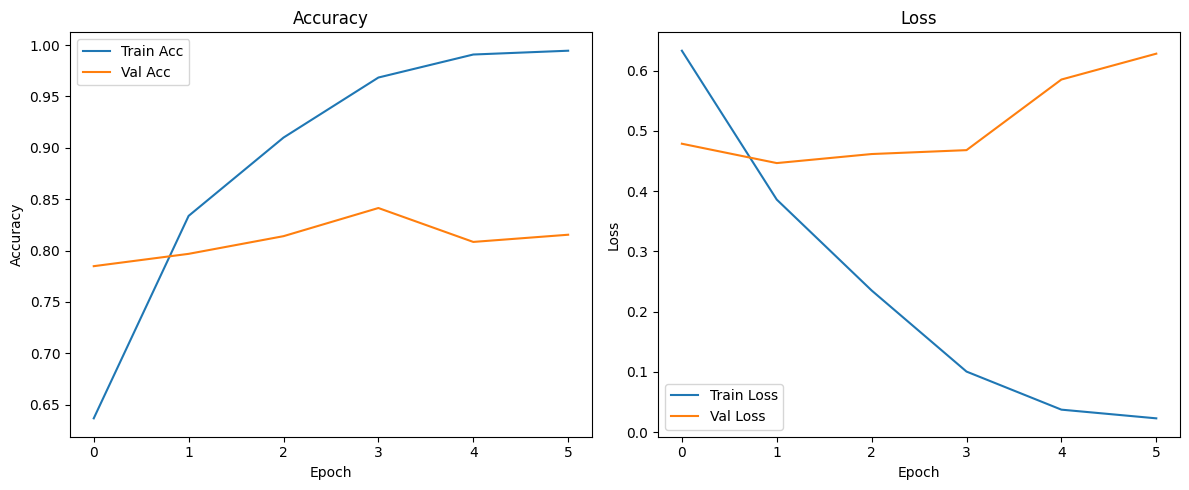

In [ ]:
plot_training_curves(history_rnn)

In [ ]:
# Evaluate RNN model on test set
loss, acc = model_rnn.evaluate(X_test, y_test)
model_accuracies['RNN'] = acc
print(f"Test Accuracy: {100*acc:.2f}%")

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8051 - loss: 0.4292
Test Accuracy: 80.51%


### ✅ View Results

In [ ]:
def predict_sentiment(model, review_text, word_index, maxlen=200):
    tokens = [word_index.get(w.lower(), 2) + 3 for w in review_text.split()]
    tokens = [1] + tokens          # prepend <START>
    padded = pad_sequences([tokens], maxlen=maxlen, truncating='pre')
    prob   = model.predict(padded, verbose=0)[0][0]
    label  = 'POSITIVE 😊' if prob >= 0.5 else 'NEGATIVE 😞'
    return label, float(prob)

In [ ]:
sample_reviews = [
    "What a waste of time. The plot made no sense, the acting was terrible and the ending was completely disappointing. Avoid at all costs.",
    "A decent film with some great moments. Not perfect, but worth watching once.",
    "I fell asleep halfway through. Boring characters and a predictable storyline.",
]

In [ ]:
for i, review in enumerate(sample_reviews, 1):
    label, conf = predict_sentiment(model_rnn, review, word_index)
    print(f"\nSample {i}:")
    print(f"  Review   : {review[:80]}..." if len(review) > 80 else f"  Review   : {review}")
    print(f"  Predicted: {label}  (confidence: {conf:.4f})")


Sample 1:
  Review   : What a waste of time. The plot made no sense, the acting was terrible and the en...
  Predicted: NEGATIVE 😞  (confidence: 0.0412)

Sample 2:
  Review   : A decent film with some great moments. Not perfect, but worth watching once.
  Predicted: POSITIVE 😊  (confidence: 0.7442)

Sample 3:
  Review   : I fell asleep halfway through. Boring characters and a predictable storyline.
  Predicted: NEGATIVE 😞  (confidence: 0.0535)
